# **Student Performance Prediction** - Task 1

**By Ragini PS**


## **Problem Statement**

The objective of this project is to predict students' average academic performance using demographic and educational attributes. Multiple regression models are developed and compared to identify the best-performing algorithm.

## **Objectives**

- Perform data preprocessing
- Conduct exploratory data analysis
- Engineer useful features
- Train multiple regression models
- Compare model performance
- Identify factors affecting student performance

## **Table of Contents**

1. Project Overview
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Feature Selection
7. Model Building
8. Model Evaluation
9. Conclusion

## **1. Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/StudentsPerformance.csv')

In [ ]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
data.shape

(1000, 8)

In [ ]:
score_cols = ['math score', 'reading score', 'writing score']
data = data[(data[score_cols] <= 100).all(axis=1)]

In [ ]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### **Observations**:
 . All means of numerical columns, close between 66-69

 . Standard deviation of the math_score , reading_score & writing_score also    close around 14-15

. Minimum score of math - 0 - poor
                   writing_score - 10 - better
                   reading_score - 17 - good

**1.1** **Check for missing values**

In [ ]:
data.isnull().sum()
print(data)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [ ]:
data.duplicated().sum()

np.int64(0)

**1.3** **Average Score = (Math + Reading + Writing) / 3**

In [ ]:
data['Average_score'] = (data['math score'] + data['reading score'] + data['writing score']) / 3
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [ ]:
# Number of students with full marks and below 20 in all 3 (math,reading,writing)

math_fullmarks = data[data['math score'] == 100]['Average_score'].count()
reading_fullmarks = data[data['reading score'] == 100]['Average_score'].count()
writing_fullmarks = data[data['writing score'] == 100]['Average_score'].count()


math_below20 = data[data['math score'] <20]['Average_score'].count()
reading_below20 = data[data['reading score']< 20]['Average_score'].count()
writing_below20 = data[data['writing score'] <20]['Average_score'].count()

print('Number of students with fullmarks in maths:', math_fullmarks)
print('Number of students with fullmarks in writing:',writing_fullmarks)
print('Number of students with fullmarks in reading:',reading_fullmarks)
print('Number of students with marks below than 20 in maths:', math_below20)
print('Number of students with marks below than 20 in writitng:', writing_below20)
print('Number of students with marks below than 20 in reading:', reading_below20)

Number of students with fullmarks in maths: 7
Number of students with fullmarks in writing: 14
Number of students with fullmarks in reading: 17
Number of students with marks below than 20 in maths: 4
Number of students with marks below than 20 in writitng: 3
Number of students with marks below than 20 in reading: 1


**Observations**:

.Students performed well in reading with 17 student getting fullmarks , only one student getting below 20.

.Students performed good in writing with 14 student getting fullmarks , only 3 student getting below 20.

.Students did not performed in maths with only 7 student getting fullmarks , only 4 student getting below 20.

In [ ]:
cat_column = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for i in cat_column:
  print(data[i].value_counts())


gender
female    518
male      482
Name: count, dtype: int64
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test preparation course
none         642
completed    358
Name: count, dtype: int64


## **2. Exploratory Data Analysis (EDA)**

In [ ]:
# Create passed variable (Pass = 1, Fail = 0)
data['Average_score'] = data[score_cols].mean(axis=1)
data['Passed'] = (data['Average_score'] >= 60).astype(int)
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score,Passed
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1


**2.1.1.**	**Impact of: Gender on scores**


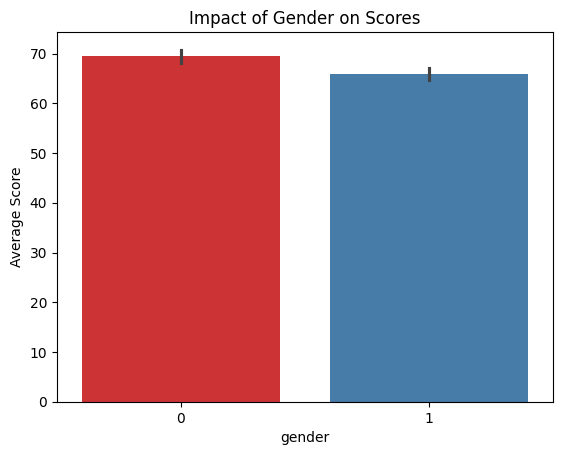

In [ ]:
sns.barplot(x='gender',y='Average_score',data=data,palette='Set1', hue='gender', legend=False)
plt.title("Impact of Gender on Scores")
plt.xlabel("gender")
plt.ylabel("Average Score")
plt.show()

### **Observation**

The average academic performance of female students is slightly higher than male students. This indicates that gender has a measurable influence on student performance in the given dataset.

**2.1.2.**	**Impact of: Parental Education**


/tmp/ipykernel_689/384766370.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='parental level of education',y='Average_score',data=data,kind='bar',palette='Set2')


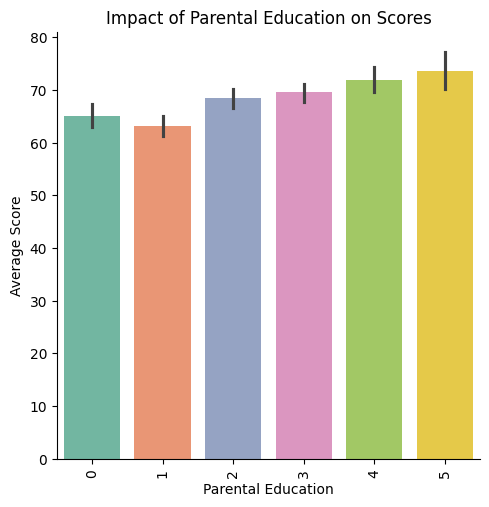

In [ ]:
sns.catplot(x='parental level of education',y='Average_score',data=data,kind='bar',palette='Set2')
plt.title("Impact of Parental Education on Scores")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")
plt.xticks(rotation=90)
plt.show()

Insights:
Students whose parents have done their master's have performed well.

**2.1.3**	**Impact of: Lunch Type**


/tmp/ipykernel_689/3719555266.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='lunch',y='Average_score',data=data,palette='Set3')


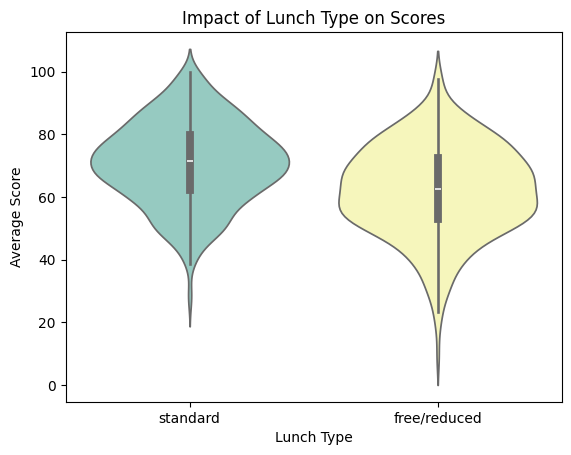

In [ ]:
sns.violinplot(x='lunch',y='Average_score',data=data,palette='Set3')
plt.title("Impact of Lunch Type on Scores")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.show()

Insights:

Average score of students with free or reduced lunch is higher than standard lunch type.

## **2.2**	**Distribution of scores**

<Figure size 100x100 with 0 Axes>

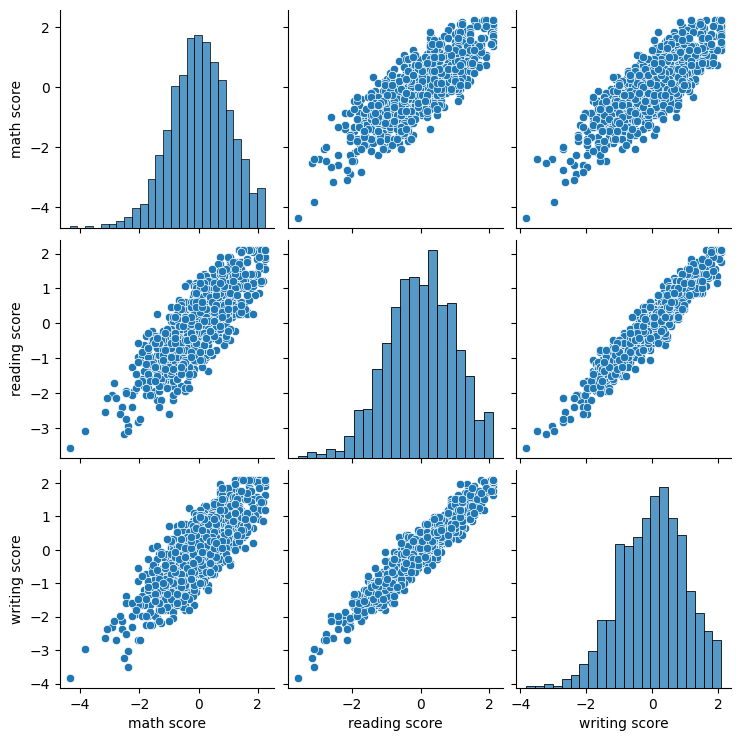

In [ ]:
Distribution_scores = data[['math score', 'reading score', 'writing score']]
plt.figure(figsize=(1,1))
sns.pairplot(Distribution_scores)
plt.show()

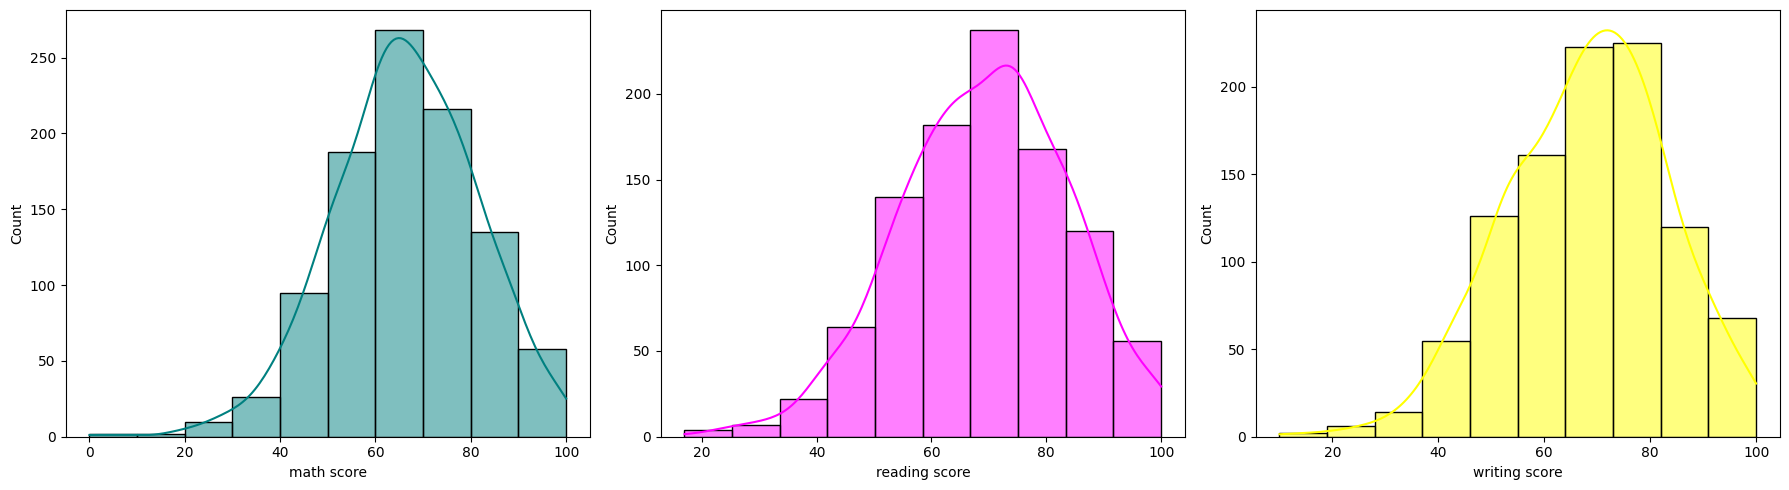

In [ ]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.histplot(data['math score'],bins=10,kde=True,color='teal')
plt.subplot(1,3,2)
sns.histplot(data['reading score'],bins=10,kde=True,color='magenta')
plt.subplot(1,3,3)
sns.histplot(data['writing score'],bins=10,kde=True,color='yellow')
plt.tight_layout()
plt.show()

## •	**1.3** **Encode categorical variables**

**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])
data['test preparation course'] = le.fit_transform(data['test preparation course'])
data['lunch'] = le.fit_transform(data['lunch'])

data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score,Passed
0,0,group B,bachelor's degree,1,1,72,72,74,72.666667,1
1,0,group C,some college,1,0,69,90,88,82.333333,1
2,0,group B,master's degree,1,1,90,95,93,92.666667,1
3,1,group A,associate's degree,0,1,47,57,44,49.333333,0
4,1,group C,some college,1,1,76,78,75,76.333333,1


**One-hot Encoding**

In [ ]:
data=pd.get_dummies(data,columns=['race/ethnicity'],drop_first=True)
data.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score,Passed,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,bachelor's degree,1,1,72,72,74,72.666667,1,True,False,False,False
1,0,some college,1,0,69,90,88,82.333333,1,False,True,False,False
2,0,master's degree,1,1,90,95,93,92.666667,1,True,False,False,False
3,1,associate's degree,0,1,47,57,44,49.333333,0,False,False,False,False
4,1,some college,1,1,76,78,75,76.333333,1,False,True,False,False


**Ordinal Encoding**

In [ ]:
data['parental level of education'] = data['parental level of education'].map({'some high school':0, 'high school':1, 'some college':2, 'associate\'s degree':3, 'bachelor\'s degree':4, 'master\'s degree':5})
data.head()
data.shape
data.head(5)

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score,Passed,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,4,1,1,72,72,74,72.666667,1,True,False,False,False
1,0,2,1,0,69,90,88,82.333333,1,False,True,False,False
2,0,5,1,1,90,95,93,92.666667,1,True,False,False,False
3,1,3,0,1,47,57,44,49.333333,0,False,False,False,False
4,1,2,1,1,76,78,75,76.333333,1,False,True,False,False


**Standard Scaler**

In [ ]:
import sklearn.preprocessing
scaler = sklearn.preprocessing.StandardScaler()
data[['math score', 'reading score', 'writing score']] = scaler.fit_transform(data[['math score', 'reading score', 'writing score']])
data.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score,Passed,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,4,1,1,0.390024,0.193999,0.391492,72.666667,1,True,False,False,False
1,0,2,1,0,0.192076,1.427476,1.313269,82.333333,1,False,True,False,False
2,0,5,1,1,1.577711,1.770109,1.642475,92.666667,1,True,False,False,False
3,1,3,0,1,-1.259543,-0.833899,-1.583744,49.333333,0,False,False,False,False
4,1,2,1,1,0.653954,0.605158,0.457333,76.333333,1,False,True,False,False


## **2.3** **Correlation between subjects**

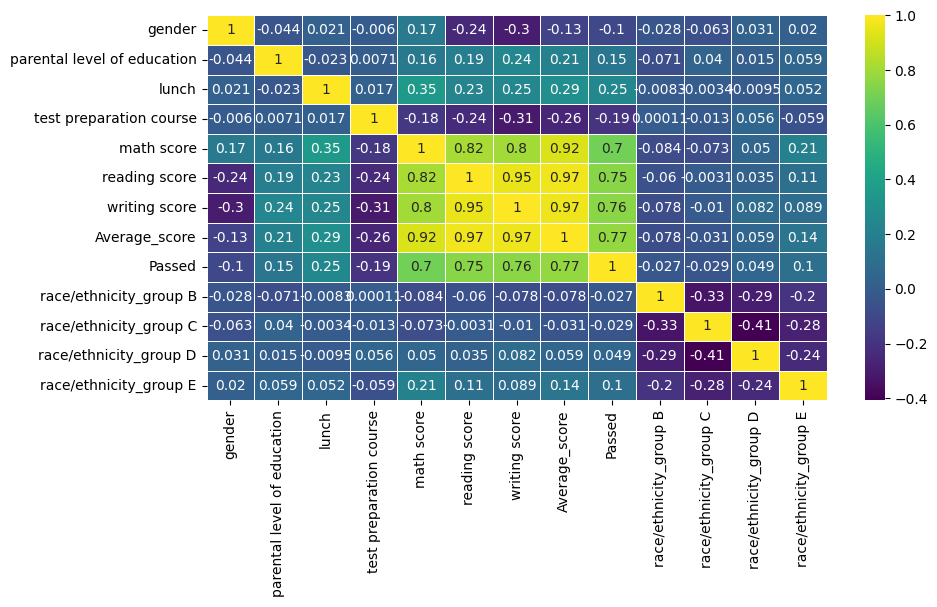

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(numeric_only = True),annot=True,cmap='viridis',linewidth=0.5)
plt.show()

## **3. Feature Selection**

## **3.1** **Important features affecting performance**

In [ ]:
from sklearn.feature_selection import SelectKBest,f_regression

x = data.drop(['math score'], axis=1)
y = data['math score']
x.shape,y.shape

((1000, 12), (1000,))

## **4.** **Model Building** **-** **Linear Regression, Decision Tree Regressor, Random Forest Regressor**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Redefine x and y to ensure all categorical features are numerical
feature = data.drop(columns=['Average_score','math score'], axis=1)
target = data['math score']

x = feature
y = target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

linear = LinearRegression()
linear_model = linear.fit(x_train, y_train)

linear_y_pred = linear_model.predict(x_test)

DT = DecisionTreeRegressor()
DT_model = DT.fit(x_train, y_train)

DT_y_pred = DT_model.predict(x_test)

RF = RandomForestRegressor()
RF_model = RF.fit(x_train, y_train)

RF_y_pred = RF_model.predict(x_test)



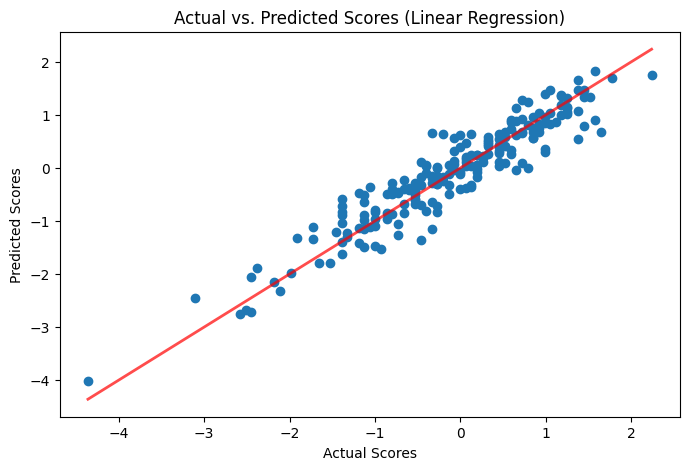

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, linear_y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red',linewidth = 2,label='Linear Regression',alpha=0.7)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs. Predicted Scores (Linear Regression)')
plt.show()

# **Feature Importance**

**For Random Forest:**

<Axes: >

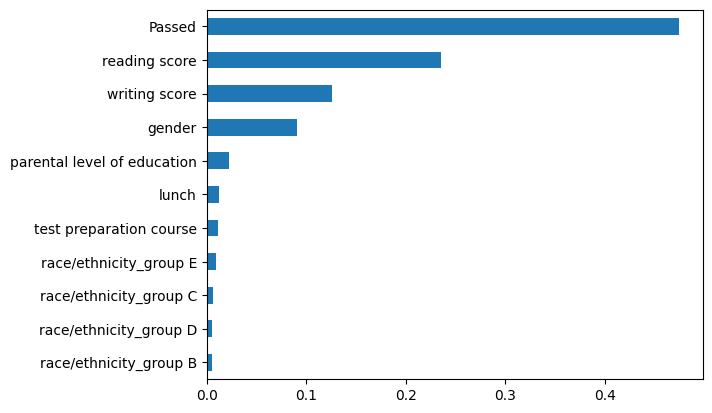

In [ ]:
importance = pd.Series(
RF_model.feature_importances_,
index=x_train.columns
)

importance.sort_values().plot.barh()

## **5.** **Model Evaluation**

### **Compare models**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
results = []
models = {
    "Linear Regression": linear_y_pred,
    "Decision Tree": DT_y_pred,
    "Random Forest": RF_y_pred
}

for model_name, y_pred in models.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "R² Score": round(r2, 3)
    })

evaluation_df = pd.DataFrame(results)

evaluation_df = evaluation_df.sort_values(by="R² Score", ascending=False)

evaluation_df

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.273,0.124,0.352,0.883
2,Random Forest,0.307,0.157,0.396,0.852
1,Decision Tree,0.416,0.298,0.546,0.719


/tmp/ipykernel_689/2712830082.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'MAE'], palette='viridis')
/tmp/ipykernel_689/2712830082.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'RMSE'], palette='plasma')
/tmp/ipykernel_689/2712830082.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'R² Score'], palette='magma')


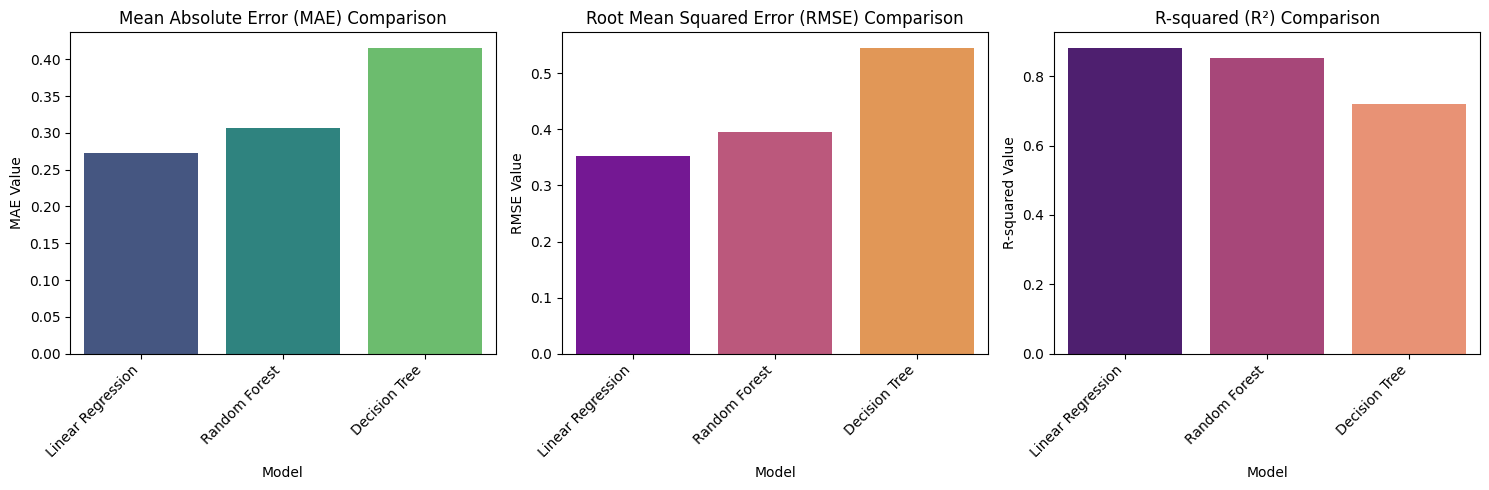

In [ ]:
metrics_df = evaluation_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'MAE'], palette='viridis')
plt.title('Mean Absolute Error (MAE) Comparison')
plt.ylabel('MAE Value')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'RMSE'], palette='plasma')
plt.title('Root Mean Squared Error (RMSE) Comparison')
plt.ylabel('RMSE Value')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='Value', data=metrics_df[metrics_df['Metric'] == 'R² Score'], palette='magma')
plt.title('R-squared (R²) Comparison')
plt.ylabel('R-squared Value')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **Difference between Actual and Predicted Values**

In [ ]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':linear_y_pred,'Difference':y_test-linear_y_pred.round(3)})
pred_df

,Actual Value,Predicted Value,Difference
521,1.643694,0.676205,0.967694
737,-0.863647,-0.494027,-0.369647
740,0.917885,0.749813,0.167885
660,0.521989,0.682479,-0.160011
411,1.181815,1.377799,-0.196185
...,...,...,...
408,-0.929630,-1.530465,0.600370
332,-0.269803,-0.293914,0.024197
208,0.521989,0.085962,0.435989
613,-0.071855,0.077978,-0.149855


## **Residual** **Plot**

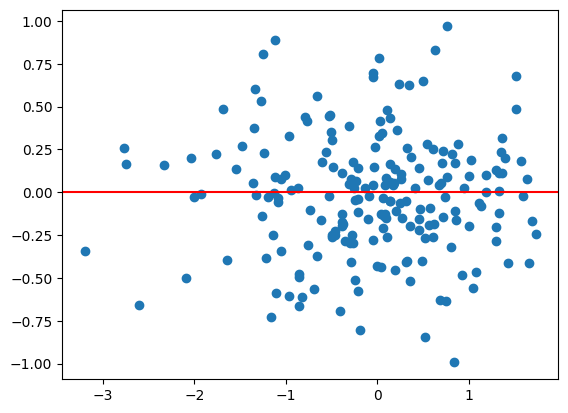

In [ ]:
residuals = y_test - linear_y_pred

plt.scatter(RF_y_pred, residuals)
plt.axhline(0,color='red')

### **Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
linear_model,
x,
y,
cv=5,
scoring='r2'
)

print(scores.mean())

0.8729554270438946
